In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
renewal_calls_df = pd.read_csv('C:\\Users\\NehaSuresh\\Downloads\\Dataset\\Dataset\\renewal_calls.csv')
display(renewal_calls_df.head())

C:\Users\NehaSuresh\AppData\Local\Temp\ipykernel_15452\3740207711.py:1: DtypeWarning: Columns (0: Churn_Category, 1: Complaint_Category, 2: Customer_Reaction_Category, 3: Agent_Renewal_Pitch_Category, 4: Customer_Renewal_Response_Category, 5: Agent_Response_Category, 6: Membership_Renewal_Decision, 7: Serious_Complaint, 8: Other_Complaint, 9: Discussion_on_Price_Increase, 10: Renewal_Impact_Due_to_Price_Increase, 11: Discount_or_Waiver_Requested, 12: Call_Reschedule_Request, 13: Agent_Flagged_Membership_Status_Alert, 14: Agent_Renewal_Initiation, 15: Explicit_Competitor_Mention, 16: Explicit_Switching_Intent, 17: Mentioned_Competitors, 18: Price_Switching_Mentioned, 19: Competitor_Value_Comparison, 20: Competitor_Benefits_Mentioned, 21: Topic_Introduced_By, 22: Percentage_Price_Increase_Mentioned, 23: Monetary_Price_Increase_Mentioned, 24: Price_Range_Mentioned, 25: Customer_Asked_For_Justification, 26: Customer_Response, 27: Desire_To_Cancel, 28: Discount_Offered, 29: Justification_Ca

,Call_ID,Call_Direction,Co_Ref,Call_Date,Churn_Category,Complaint_Category,Customer_Reaction_Category,Agent_Renewal_Pitch_Category,Customer_Renewal_Response_Category,Agent_Response_Category,...,Customer_Response,Desire_To_Cancel,Discount_Offered,Justification_Category,Reason_For_Renewal_Category,Agent_Response_To_Cancel_Category,Argument_That_Convinced_Customer_to_Stay_Category,Analysed_Call,Call_Number,Call_Year
0,5.950000e+11,Outbound,UB0899,29-01-2025,NaN,NaN,Not Mentioned,Discussion / Introduction / Inquiry,Discount and Offer,Discount and Offer,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,3,2025
1,5.970000e+11,OUT_BOUND,HN5141,26-02-2025,NaN,NaN,NaN,Price and Cost,Agreement,Customer Communication,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,2,2025
2,5.950000e+11,Outbound,BP5009,24-01-2025,NaN,NaN,NaN,Expiration / Due,Agreement,Accreditation and Certification,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,1,2025
3,6.520000e+11,OUT_BOUND,XP8119,09-06-2025,NaN,NaN,NaN,Auto / Automatic,Agreement,Accreditation and Certification,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,1,2025
4,5.370000e+11,Outbound,ZL7978,20-08-2024,NaN,NaN,NaN,NaN,NaN,NaN,...,Not Discussed,Not Discussed,No,NaN,NaN,NaN,NaN,1.0,28,2024


In [5]:
renewal_calls_df.shape

(186534, 41)

In [4]:
renewal_calls_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 186534 entries, 0 to 186533
Data columns (total 41 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   Call_ID                                            186534 non-null  float64
 1   Call_Direction                                     186534 non-null  str    
 2   Co_Ref                                             179149 non-null  str    
 3   Call_Date                                          186534 non-null  str    
 4   Churn_Category                                     7902 non-null    str    
 5   Complaint_Category                                 19008 non-null   str    
 6   Customer_Reaction_Category                         23085 non-null   str    
 7   Agent_Renewal_Pitch_Category                       53738 non-null   str    
 8   Customer_Renewal_Response_Category                 54312 non-null   str    
 9   Agen

Price Increase Impact (%):
 Membership_Renewal_Decision           No        Yes     Yes/No
Discussion_on_Price_Increase                                  
**No**                        100.000000   0.000000   0.000000
No                             90.414156   9.576869   0.008976
Yes                            81.506329  18.493671   0.000000
[Yes/No]                       76.923077   0.000000  23.076923

Competitor Mention Impact (%):
 Membership_Renewal_Decision          No        Yes      Yes/No
Explicit_Competitor_Mention                                   
No                            89.793162  10.193918    0.012920
Prompt 2:                    100.000000   0.000000    0.000000
UNAVAILABLE                    0.000000   0.000000  100.000000
XXXX                          94.117647   0.000000    5.882353
Yes                           76.330935  23.669065    0.000000
[No]                         100.000000   0.000000    0.000000

Discount Effectiveness (%):
 Membership_Renewal_Decision

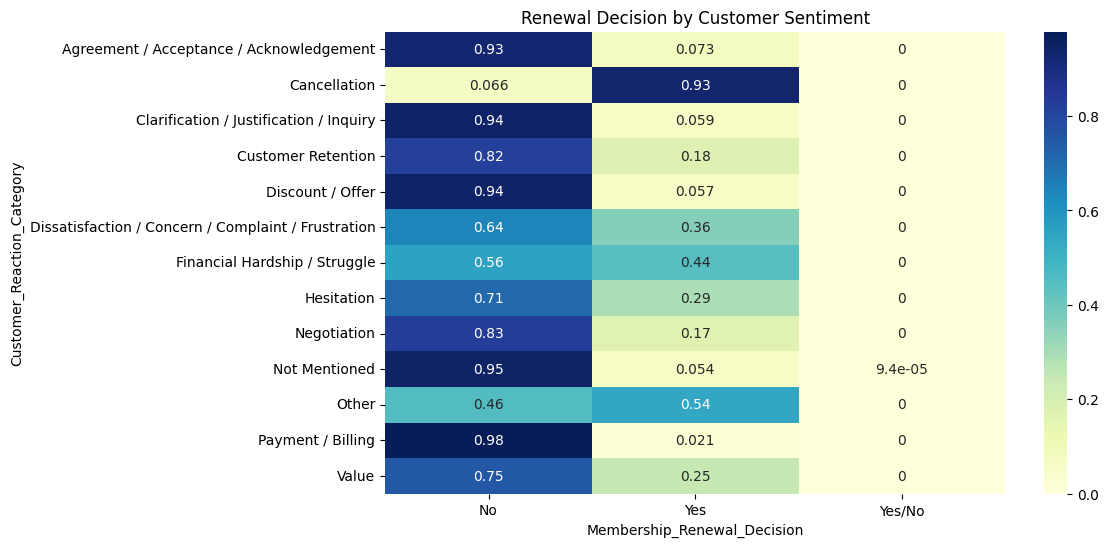

In [7]:
# 1. Price Increase Impact
# Shows the percentage of renewals when a price increase was discussed vs. not.
price_impact = pd.crosstab(renewal_calls_df['Discussion_on_Price_Increase'], 
                           renewal_calls_df['Membership_Renewal_Decision'], 
                           normalize='index') * 100
print("Price Increase Impact (%):\n", price_impact)

# 2. Competitor Mention Impact
# High percentages of 'No' here indicate your pricing or features are losing to rivals.
comp_impact = pd.crosstab(renewal_calls_df['Explicit_Competitor_Mention'], 
                          renewal_calls_df['Membership_Renewal_Decision'], 
                          normalize='index') * 100
print("\nCompetitor Mention Impact (%):\n", comp_impact)

# 3. Discount Effectiveness
# Check if offering a discount actually leads to a 'Yes'.
discount_impact = pd.crosstab(renewal_calls_df['Discount_Offered'], 
                              renewal_calls_df['Membership_Renewal_Decision'], 
                              normalize='index') * 100
print("\nDiscount Effectiveness (%):\n", discount_impact)

# 4. Visualize the relationship with a Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(renewal_calls_df['Customer_Reaction_Category'], 
                        renewal_calls_df['Membership_Renewal_Decision'], 
                        normalize='index'), 
            annot=True, cmap="YlGnBu")
plt.title("Renewal Decision by Customer Sentiment")
plt.show()

In [9]:
bill_df=pd.read_csv(r'C:\Users\NehaSuresh\Downloads\Dataset\Dataset\billings.csv')
display(bill_df.head())

C:\Users\NehaSuresh\AppData\Local\Temp\ipykernel_15452\356158174.py:1: DtypeWarning: Columns (0: Proforma_Auto_Renewal, 1: Proforma_World_Pay_Token, 2: Current_Anchor_List, 3: Last_Renewal, 4: Last_Band) have mixed types. Specify dtype option on import or set low_memory=False.
  bill_df=pd.read_csv(r'C:\Users\NehaSuresh\Downloads\Dataset\Dataset\billings.csv')


,Co_Ref,Renewal_Month,Connection_Net,Connection_Qty,Discount_Amount,Sustainability_Score,Total_Renewal_Score_New,Starting_Connection_Net,Starting_Connection_Qty,Last_Years_Price,...,Connection_Group,Tenure_Group,#_of_Connection,Last_Renewal,Last_Band,Last_Total_Net_Paid,Last_Connections,Anchor_Group,Renewal_Year,DateTime_Out
0,VT6174,01-11-2024,NaN,NaN,NaN,8.0,42.5,NaN,NaN,799.0,...,1,3,1.0,01-11-2023,Band B,664.0,1.0,1,2024,01-11-2024
1,VD3828,01-08-2025,NaN,NaN,NaN,8.0,41.5,NaN,NaN,799.0,...,1,1,1.0,NaN,NaN,NaN,NaN,1,2025,01-08-2025
2,DV8120,01-03-2025,NaN,NaN,NaN,8.0,33.0,NaN,NaN,799.0,...,1,4+,1.0,01-03-2024,Band C1,749.0,1.0,1,2025,01-03-2025
3,EZ9894,01-06-2025,NaN,NaN,NaN,9.5,44.5,NaN,NaN,799.0,...,1,4+,1.0,01-06-2024,Band C1,749.0,1.0,1,2025,01-06-2025
4,FA8957,01-03-2025,NaN,NaN,NaN,9.5,42.5,NaN,NaN,799.0,...,1,3,1.0,01-03-2024,Band C1,749.0,1.0,1,2025,01-03-2025


In [10]:
bill_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122082 entries, 0 to 122081
Data columns (total 59 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Co_Ref                      122082 non-null  str    
 1   Renewal_Month               122082 non-null  str    
 2   Connection_Net              8037 non-null    float64
 3   Connection_Qty              8037 non-null    float64
 4   Discount_Amount             13551 non-null   str    
 5   Sustainability_Score        122082 non-null  float64
 6   Total_Renewal_Score_New     122082 non-null  float64
 7   Starting_Connection_Net     8545 non-null    float64
 8   Starting_Connection_Qty     8545 non-null    float64
 9   Last_Years_Price            112992 non-null  float64
 10  Last_Years_Date_Paid        0 non-null       float64
 11  Auto_Renewal_Score          122082 non-null  int64  
 12  Status_Scores               122082 non-null  int64  
 13  Anchoring_Score          